# Task 1: Passing Accuracy
## Analytic Task Overview
**Analytic question formulation:**
Is there a significant difference in the mean passing accuracy of midfielders and defenders who played during the FIFA World Cup 2026? Players with no recorded pass attempts are excluded.

**Data wrangling:**
Player details and passing statistics were obtained from FIFA's official player-statistics page using Python. The required fields were extracted from the structured data supplied to the browser and organised in a pandas DataFrame( Fédération Internationale de Football Association [FIFA], 2026; McKinney, 2010; Microsoft, n.d.-a, n.d.-b)

**Data preparation and sampling:**
Records were checked for missing values and duplicate player identifiers. Players were eligible when their position was midfielder (`MF`) or defender (`DF`) and they attempted at least one pass.

Separate simple random samples of 40 eligible players per group were selected using `random_state = 140`, which makes the selection reproducible when the same ordered data are used (pandas development team, n.d.-b).

**Descriptive statistics:**
The two samples were summarised using mean, median, standard deviation, minimum, maximum and quartiles. A box plot was used to compare their centres, spreads and possible unusal values (National Institute of Standards and Technology [NIST], 2012; pandas development team, n.d.-b).

**Inferential statistics:**
A 95% Welch confidence interval was calculated for the difference in population means (`MF - DF`).

A two-sided Welch independent-samples t-test then assessed whether the observed diference was statistically distinguishable from zero. Welch's method is suitable for independent samples and does not require the two population variances to be equal (SciPy community, n.d.; Welch 1947).


### Variables
The quantitative variable is **passing accuracy** measured as a percentage

The categorical variable is **player position**, with midfielders (`MF`) and defenders (`DF`) used as the two groups for comparison.

The unit of analysis is **one player**.

# Preparing Google Colab for browser collection
The next cell prepares Colab, we install Chrome, Playwright and Xvfb for the current session.

`%%writefile` is used to save the complete cell as a pythin script (IPython Development Team, n.d.)

Collab normally runs without a desktop screen, so Xvfb creates a temporary virtual display so that Chrome can run in headed mode.

Tutorials used
https://ipython.readthedocs.io/en/stable/interactive/magics.html

https://manpages.ubuntu.com/manpages/noble/man1/xvfb-run.1.html

https://playwright.dev/python/docs/intro

In [88]:
# Installs the browser tools used for data collection. See Microsoft (n.d.-a, n.d.-b)
# These commands prepare Colab environment;
!apt-get update -qq
!apt-get install -y xvfb wget

!wget -q https://dl.google.com/linux/direct/google-chrome-stable_current_amd64.deb
!apt-get install -y ./google-chrome-stable_current_amd64.deb

!pip install -q playwright

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
wget is already the newest version (1.21.2-2ubuntu1.5).
xvfb is already the newest version (2:21.1.4-2ubuntu1.7~22.04.16).
0 upgraded, 0 newly installed, 0 to remove and 86 not upgraded.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'google-chrome-stable' instead of './google-chrome-stable_current_amd64.deb'
google-chrome-stable is already the newest version (153.0.8010.36-1).
0 upgraded, 0 newly installed, 0 to remove and 86 not upgraded.


In [66]:
# Libraries used for browser automation, tabular data, statistics and charts.
# Method sources: Mckinney (210), Microsoft (n.d.-a, n.d.-b), pandas development team (n.d.-b),
# Matplotlib development team (n.d.) and SciPy community (n.d.).
import asyncio
import json
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from pathlib import Path
from scipy import stats

## Data Wrangling
The data for this task were obtained from the official FIFA World Cup 2026 player statistics page (FIFA, 2026).

The FIFA statistics page is dynamically rendered: The browser loads the page and then recieved the player statistics through network requests.

Playwright was used becauce it can monitor browser request and response traffic. (Microsoft, n.d.-a, n.d-b).

Chrome fist opens the real FIFA page. The code observes the page's network traffic, obtains the FIFA access token and requests paginated JSON records.

It uses Playwright which controls a browser.
The browser steps use async/await because of network responses take time and we make use of asyncio which starts the program asycnchronously (Python Software Foundation, n.d.-a; Microsoft, n.d.-d).

Tutorials used
https://docs.python.org/3/library/asyncio.html

https://playwright.dev/python/docs/intro

https://playwright.dev/python/docs/network

In [86]:
%%writefile fifa_real_browser.py

import asyncio
import json
from playwright.async_api import async_playwright

# FIFA (2026) is the primary data source. Playwright's documented network events allow
# Python to observe the responses loaded by a dynamic webpage (Microsoft, n.d.-b).

FIFA_URL = ("https://www.fifa.com/en/tournaments/mens/worldcup/canadamexicousa2026/statistics/player-statistics")

async def main():
  async with async_playwright() as p:
    # Playwright's BrowserType.launch() supports the execulable_path,
    # headless and args options used below (Microsoft, n.d.-a).

    # Use the Google Chrome installed in Colab,
    # and run it in HEADED mode.
    browser = await p.chromium.launch(
        executable_path="/usr/bin/google-chrome",
        headless=False,
        args=["--no-sandbox", "--disable-dev-shm-usage", "--window-size=1440,1200"]
    )

    context = await browser.new_context(
        viewport={"width": 1440, "height": 1200},
        locale="en-AU"
    )

    page = await context.new_page()

    successful = []
    failed = []

    # Watch real GameDay responses
    # page.on('response', ...) follows Playwright's network-event approach
    # documented by Microsoft (n.d.-b).
    async def response_handler(response):
      if "gameday-prod.fifa.mangodev.co.uk" in response.url:
        print("\nGAMEDAY RESPONSE")
        print("Status:", response.status)
        print("URL:", response.url)

        if response.status == 200:
          successful.append(response.url)

          try:
            data = await response.json()

            if isinstance(data, dict):
              print("JSON keys:", list(data.keys()))

          except Exception as e:
            print("JSON read error:", e)

    # Check for failures
    async def failure_handler(request):
      if "gameday-prod.fifa.mangodev.co.uk" in request.url:
        failed.append(request.url)
        print("\nGAMEDAY FAILED")
        print("URL:", request.url)
        print("Reason:", request.failure)

    page.on("response", response_handler)
    page.on("requestfailed", failure_handler)

    print("Opening FIFA...")

    response = await page.goto(FIFA_URL, wait_until="domcontentloaded", timeout=90000)

    print("\nFIFA page status:", response.status)

    # Give FIFA's JS plenty of time
    await page.wait_for_timeout(20000)

    print("\nSUMMARY")
    print("Successful requests:", len(successful))
    print("Failed requests:", len(failed))

    await browser.close()

asyncio.run(main())

Overwriting fifa_real_browser.py


In [87]:
# xvfb-run executes the Python script within a virtual display environment
# The - a optionally automatcally selects an available server number (Canonical Ltd., n.d.).
!xvfb-run -a python fifa_real_browser.py

Opening FIFA...

FIFA page status: 200

GAMEDAY RESPONSE
Status: 200
URL: https://gameday-prod.fifa.mangodev.co.uk/1-0/teams?query=_externalCompetitionId==`285023`
JSON keys: ['matchCount', 'index', 'requestCount', 'count', 'anotherPage', 'nextPageUrl', 'items']

GAMEDAY RESPONSE
Status: 200
URL: https://gameday-prod.fifa.mangodev.co.uk/1-0/stories?query=(and%20resourceStatus==`urn:gd:resourceStatus:active`%20_externalId~`urn:gd:story:classification:gcp_top_scorer:competitionId:285023:(.*):rank_asc:page:1$`)&skip=0&limit=1&sort=tags.name==urn:gd:tag:story:fifa:column_number:asc
JSON keys: ['matchCount', 'index', 'requestCount', 'count', 'anotherPage', 'nextPageUrl', 'items']

GAMEDAY RESPONSE
Status: 200
URL: https://gameday-prod.fifa.mangodev.co.uk/1-0/stories?query=(and%20resourceStatus==`urn:gd:resourceStatus:active`%20_externalId~`urn:gd:story:classification:gcp_top_scorer:competitionId:285023:goals:rank_asc:page:1$`)&skip=0&limit=1&sort=tags.name==urn:gd:tag:story:fifa:column_numb

# Manual Inspection to automated request

The FIFA-specific address and labels in the next script were identified manually examining how the FIFA site behaved.

1. Open the FIFA page in Chrome
2. Open Developer tools -> Network and reload the page
3. Filter the network list for Fetch/XHR requests.
4. Change the statistics category and page number on the FIFA site.
5. Compare the request URL, query, headers and JSON response.
6. Record which parts stayed fixed and which part changed number.

Tutorials used:
https://playwright.dev/python/docs/evaluating

https://developer.mozilla.org/en-US/docs/Web/API/Fetch_API/Using_Fetch

https://developer.mozilla.org/en-US/docs/Web/JavaScript/Reference/Global_Objects/encodeURIComponent


In [48]:
%%writefile fifa_collect_passing.py

import asyncio
import json
from playwright.async_api import async_playwright
from pathlib import Path

# FIFA (2026) is the primary data source. The collection method uses Playwright's documented
# page.evaluate() and network capabilities (Microsoft, n.d.-b).

FIFA_URL = ("https://www.fifa.com/en/tournaments/mens/worldcup/canadamexicousa2026/statistics/player-statistics")

async def main():
  async with async_playwright() as p:
     # Playwright's BrowserType.launch() supports the execulable_path,
    # headless and args options used below (Microsoft, n.d.-a).

    # Use the Google Chrome installed in Colab,
    # and run it in HEADED mode.
    browser = await p.chromium.launch(
        executable_path="/usr/bin/google-chrome",
        headless=False,
        args=["--no-sandbox", "--disable-dev-shm-usage", "--window-size=1440,1200"]
    )

    context = await browser.new_context(
        viewport={"width": 1440, "height": 1200},
        locale="en-AU"
    )

    page = await context.new_page()

    print("Opening FIFA...")

    response = await page.goto(FIFA_URL, wait_until="domcontentloaded", timeout=90000)

    print("\nFIFA page status:", response.status)

    # Give FIFA's JS plenty of time
    await page.wait_for_timeout(12000)

    # Get token using FIFA's own token endpoint
    # page.evaluate() runs JS in the webpage context and returns its result to Python (Microsoft, n.d.-a).
    token = await page.evaluate("""
    async () => {
      const response = await fetch("https://cxm-api.fifa.com/fifaplusweb/api/external/gameDay/token");
      const data = await response.json();
      return data.token;
    }
    """)

    print("Token obtained")

    # Manual inspection of the FIFA passing table showed 25 pages at the time of collection.
    # The page number also appeared within the request query (FIFA, 2026; Microsoft, n.d.-c).
    # EncodedURIComponent() was applied because the query contains spaces, colons,
    # backticks and other characters that must be safely included in a URL (Mozilla, n.d.-a),
    all_pages = []
    for page_number in range (1, 26):
      print(f"Collecting passing page {page_number}...")
      result = await page.evaluate(
        """
        async ({token, pageNumber}) => {
          const query =
            "(and resourceStatus==`urn:gd:resourceStatus:active` " +
            "_externalId~`urn:gd:story:classification:" +
            "gcp_distribution:" +
            "competitionId:285023:" +
            "passes:" +
            "rank_asc:" +
            "page:" + pageNumber + "$`)";

          const url =
            "https://gameday-prod.fifa.mangodev.co.uk/1-0/stories" +
            "?query=" + encodeURIComponent(query) +
            "&skip=0" +
            "&limit=1" +
            "&sort=" +
            encodeURIComponent(
                "tags.name==urn:gd:tag:story:fifa:column_number:asc"
            );

          const response = await fetch(
              url,
              {
                headers: {
                  "Authorization": "Bearer " + token,
                  "Accept": "application/json, text/plain, */*"
                }
              }
            );

            const text = await response.text();

            return {
                status: response.status,
                url: url,
                text: text
            };
        }
        """,
        {"token": token, "pageNumber": page_number}
      )

      print("Status:", result["status"])

      if result["status"] != 200:
        print("Stopped because page", page_number, "returned", result["status"])
        print(result["text"][:500])
        break

      data = json.loads(result["text"])

      all_pages.append({"page_number": page_number, "url": result["url"], "data": data})

      # Although manual inspection found 25 pages,
      # Stop early if FIFA returns a page containing no player records
      items = data.get("items", [])
      if not items:
        print("No items returned")
        break

  # Save FIFA JSON
  Path("fifa_passing_raw.json").write_text(
      json.dumps(all_pages, indent=2, ensure_ascii=False), encoding="utf-8"
  )

  print("\nCOLLECTION COMPLETE")
  print("Pages captured:", len(all_pages))
  print("Saved: fifa_passing_raw.json")

  await browser.close()

asyncio.run(main())

Overwriting fifa_collect_passing.py


In [49]:
# xvfb-run executes the Python script within a virtual display environment
# The - a optionally automatcally selects an available server number (Canonical Ltd., n.d.).
!xvfb-run -a python fifa_collect_passing.py

Opening FIFA...

FIFA page status: 200
Token obtained
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200
Status: 200

COLLECTION COMPLETE
Pages captured: 25
Saved: fifa_passing_raw.json


The collection script saves FIFA's responses before any filtering or sampling, this creates a checkable copy.

`json.load()` converts the file into Python dictionaries and lists

Tutorial used
https://docs.python.org/3/library/json.html


In [51]:
# Load the saved FIFA JSON into python lists and dictionaries
# (Python Software Foundation, n.d.)
with open("fifa_passing_raw.json", "r", encoding="utf-8") as file:
  raw_pages = json.load(file)

# Confirm that the expected number of FIFA pages was loaded
print("Pages loaded:", len(raw_pages))

Pages loaded: 25


In [52]:
# Inspect one representative page
first_page = raw_pages[0]["data"]

print(first_page.keys())
print("Number of story items:", len(first_page["items"]))

dict_keys(['matchCount', 'index', 'requestCount', 'count', 'anotherPage', 'nextPageUrl', 'items'])
Number of story items: 1


In [53]:
# Examone the structure of a FIFA story
story = first_page["items"][0]
print(story.keys())

dict_keys(['_id', '_externalId', '_externalIdScope', 'classification', 'shortName', 'name', 'shortDescription', 'longDescription', 'actors', 'sidecar', 'resourceType', 'resourceStatus', 'sportType', 'defaultLanguage', 'documents', 'audios', 'videos', 'images', 'tags', 'createdAt', 'updatedAt'])


In [54]:
# Locate the nested player records and tags
print(json.dumps(story, indent=2)[:8000])

{
  "_id": "6a2a8b5f5706a5d7f7e225f5",
  "_externalId": "urn:gd:story:classification:gcp_distribution:competitionId:285023:passes:rank_asc:page:1",
  "_externalIdScope": "fifa",
  "classification": "urn:gd:story:classification:gcp_distribution:competitionId:285023:passes:rank_asc:page:1",
  "shortName": null,
  "name": {
    "eng": "FIFA World Cup 2026\u2122 stats story \"gcp_distribution\", ranked by PASSES [ascending] - page 1/25"
  },
  "shortDescription": null,
  "longDescription": null,
  "actors": [
    {
      "key": {
        "keyType": "staff",
        "_externalTeamId": "285023_43969",
        "_externalTeamIdScope": "fifa",
        "_externalSportsPersonId": "411375",
        "_externalSportsPersonIdScope": "fifa"
      },
      "number": 1,
      "name": {
        "eng": "Rodri",
        "spa": "Rodri",
        "fra": "Rodri",
        "deu": "Rodri",
        "ara": "\u0631\u0648\u062f\u0631\u064a",
        "por": "Rodri",
        "jpn": "\u30ed\u30c9\u30ea",
        "ita": 

### Initial dataset
After extracting the player records from the 25 collected FIFA passing-statistics pages, the initial dataset contained **1,242 player records**.

The JSON was tramsformed into a pandas DataFrame so each row represents one player and each column represents one variable (McKinney, 2010; pandas development team, n.d.-b).

The extracted variables were:
- `PlayerID` - FIFA player identifier
- `Player` - player name
- `Team` - national team
- `TeamAbbreviation` - three-letter team abbreviation
- `Position` - player position
- `Passes` - number of passes recorded by FIFA
- `PassingAccuracy` - passing accuracy rate recorded by FIFA
- `Rank` - player's rank in the FIFA pasing statistics

Inspection of one story showed that player records were stored under `actors`.

Each actor contained nested fields such as player's name and a tags list containing pairs named `name` and `value`

A helper function was needed to convert the list into a python dictionary.

Tutorials used
https://docs.python.org/3/tutorial/datastructures.html

https://pandas.pydata.org/docs/getting_started/intro_tutorials/03_subset_data.html



In [57]:
# Convert nested FIFA JSON fields into one row per player and named columns.
# This is supported by pandas (McKinney, 2010; pandas development team, n.d.-b).
def get_tags(actor):
  return {
      tag["name"]: tag["value"]
      for tag in actor.get("tags", [])
  }

players = []

for page in raw_pages:
  story_items = page["data"].get("items", [])

  for story in story_items:

    actors = story.get("actors", {})

    for actor in actors:
      tags = get_tags(actor)
      players.append({
          "PlayerID": actor.get("key", {}).get("_externalSportsPersonId"),
          "Player": actor.get("name", {}).get("eng"),
          "Team": tags.get("urn:gd:tag:story:team:name:eng"),
          "TeamAbbreviation": tags.get("urn:gd:tag:story:team:abbreviation"),
          "Position": tags.get("urn:gd:tag:story:staff:position"),
          "Passes": tags.get("urn:gd:tag:football:stats:passes"),
          "PassingAccuracy": tags.get("urn:gd:tag:football:stats:passing_accuracy_rate"),
          "Rank": tags.get("urn:gd:tag:story:staff:rank"),
      })

passing_df = pd.DataFrame(players)

passing_df.head()

,PlayerID,Player,Team,TeamAbbreviation,Position,Passes,PassingAccuracy,Rank
0,411375,Rodri,Spain,ESP,MF,799,93,1
1,474973,Pau Cubarsi,Spain,ESP,DF,690,97,2
2,335999,Aymeric Laporte,Spain,ESP,DF,660,94,3
3,332847,Leandro Paredes,Argentina,ARG,MF,565,94,4
4,405841,Marc Guehi,England,ENG,DF,532,97,5


In [58]:
# Inspect column names, data types and non-missing counts
passing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1242 entries, 0 to 1241
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   PlayerID          1242 non-null   object
 1   Player            1242 non-null   object
 2   Team              1242 non-null   object
 3   TeamAbbreviation  1242 non-null   object
 4   Position          1242 non-null   object
 5   Passes            1242 non-null   int64 
 6   PassingAccuracy   1242 non-null   int64 
 7   Rank              1242 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 77.8+ KB


In [59]:
# Check whether the FIFA player identifier appears more than once.
print("Duplicate Player IDs:", passing_df["PlayerID"].duplicated().sum())

Duplicate Player IDs: 0


In [60]:
# Check whether analysis variable is missing.
print("Missing passing accuracy:", passing_df["PassingAccuracy"].isna().sum())
print("Missing position:", passing_df["Position"].isna().sum())

Missing passing accuracy: 0
Missing position: 0


In [61]:
print(passing_df["Position"].value_counts())

Position
DF    417
MF    368
FW    312
GK    145
Name: count, dtype: int64


### Data Preparation and Sampling

The initial data contained 417 defenders and 368 midfielders. After restricting the population to exclude players wit `Passes = 0`, the eleigible populations contained 344 defenders and 327 midfielders. This left 671 eligible players.

Separate simple random samples of 40 midfielders and 40 defenders were selected with `DataFrame.sample()`. The fixed value `random_state = 140` makes the selection reproducible. (pandas development team, n.d.-a).

In [62]:
# Keep only midfielders and defenders
task1_df = passing_df[passing_df["Position"].isin(["MF", "DF"])].copy()

# Remove players who did not attempt any passes
task1_df = task1_df[task1_df["Passes"] > 0]

print("\nRows after position filtering:", len(task1_df))
print(task1_df["Position"].value_counts())


Rows after position filtering: 671
Position
DF    344
MF    327
Name: count, dtype: int64


In [63]:
# Set sample size
sample_size = 40

# fixed random seed so the same sample can be reproduced
random_seed = 140

mf_sample = task1_df[task1_df["Position"] == "MF"].sample(n=sample_size, random_state=random_seed)
df_sample = task1_df[task1_df["Position"] == "DF"].sample(n=sample_size, random_state=random_seed)

## Descriptive Statistics
Descriptive statistics summarise the main characteristice of the two samples.

use `DataFrame.describe()` to calculate count, mean, standard deviation, minimum quartile and maximum (pandas development team, n.d.-b).

Following statistics are calculated fro `PassingAccuracy` for each player group:
- sample size (`n`)
- mean
- median
- standard deviation
- minimum
- first quartile (`Q1`)
- third quartile (`Q3`)
- maximum

### Interpretation of descriptive statistics
Sample Mean
- Midfielder: 83.50%
- Defender: 87.53%
- Difference: -4.03 pp (MF-DF)

Median
- Midfielder: 86.00%
- Defender: 91.00%

Standard deviation
- Midfielder: 13.85%
- Defender: 10.16%

Quartiles
- Midfielder ranged from 79.00% to 91.00%
- Defender ranged from 83.75% to 94.00%

Minimum and Maximum (respectively)
- Midfielder (33%, 100%)
- Defender (50%, 100%)

# Boxplot use
Boxplot displays median, quartiles and spread makingn it easier to inspect (NIST, 2012; pandas development team, n.d.-b).

In [64]:
# Dataframe.describe() returns count, mean, standard deviation, quartiles and range
# for numeric variables (pandas development team, n.d.).
mf_stats = mf_sample["PassingAccuracy"].describe()
df_stats = df_sample["PassingAccuracy"].describe()

print("Midfielders:")
print(mf_stats)

print("\nDefenders:")
print(df_stats)

Midfielders:
count     40.000000
mean      83.500000
std       13.847151
min       33.000000
25%       79.000000
50%       86.000000
75%       91.000000
max      100.000000
Name: PassingAccuracy, dtype: float64

Defenders:
count     40.000000
mean      87.525000
std       10.162746
min       50.000000
25%       83.750000
50%       91.000000
75%       94.000000
max      100.000000
Name: PassingAccuracy, dtype: float64


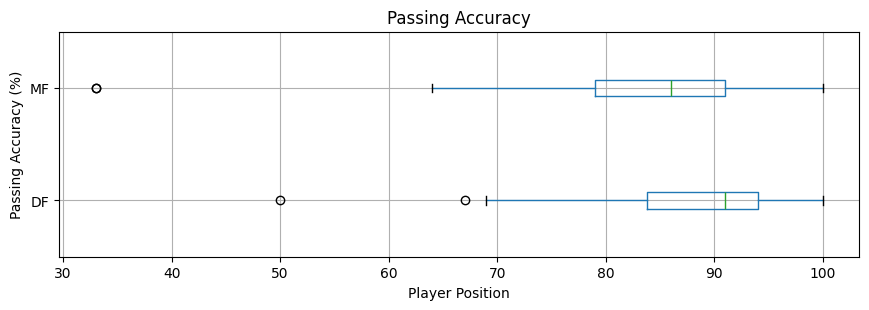

<Figure size 640x480 with 0 Axes>

In [82]:
# Combine the two samples for plotting
# Side-by-side boxplots compare group centre and spread
# (National Institute of Standards and Technology [NIST], 2012).
plot_df = pd.concat([mf_sample.assign(Group="Midfielder"), df_sample.assign(Group="Defender")])
plot_df.boxplot(column="PassingAccuracy", by="Position", vert=False, figsize=(10, 3))

plt.title("Passing Accuracy")
plt.suptitle("")
plt.xlabel("Player Position")
plt.ylabel("Passing Accuracy (%)")
plt.show()

plt.tight_layout()
plt.show()

## Inferential Statistics - Confidence Interval
The difference between the eligible midfielder and defender population means.

95% Welch confidence interval was caluclated for the mean difference because the samples are independent and variances are not assumed to be equal(Welch, 1947).

`errorbar()` is used toat sero to represent no difference (Matplotlib development team, n.d.-b).

The sample difference: -4.03 pp (MF - DF)
95% confidence intervale: -9.44 to 1.39 pp.

Tutorials used
https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.t.html

In [73]:
# This analysis follows the CI procedures introduced in
# HIT140 Week 3 and the independent two-sample t-test introduced in Week 4
# (Charles Darwin University, 2026a, 2026b).
#
# Utilising the Welch's degrees of freedom and a 95% CI
# for the difference between the two population means (Welch, 1947).
#
# Scipy documentation was used for implementation of stats.sem(),
# stats.t.interval(), stats.t.ppf() and stats.ttest_ind()
# Passing accuracy values from the two random samples
mf_values = mf_sample["PassingAccuracy"].dropna().astype(float)
df_values = df_sample["PassingAccuracy"].dropna().astype(float)

# Sample sizes
n_mf = len(mf_values)
n_df = len(df_values)

# Means and Variances
mean_mf = mf_values.mean()
mean_df = df_values.mean()

var_mf = mf_values.var(ddof=1)
var_df = df_values.var(ddof=1)

# 95% CI for each population mean
mf_ci = stats.t.interval(confidence=0.95, df=n_mf - 1, loc=mean_mf, scale=stats.sem(mf_values))
df_ci = stats.t.interval(confidence=0.95, df=n_df - 1, loc=mean_df, scale=stats.sem(df_values))

mean_difference = mean_mf - mean_df

standard_error = np.sqrt((var_mf / n_mf) + (var_df / n_df))

# Calculate degree of freedom using the
# Welch-Satterthwaite equation (Satterthwaite, 1946; Welch, 1947).
welch_df = (
    (var_mf / n_mf + var_df / n_df) ** 2 /
    (
      ((var_mf / n_mf) ** 2 / (n_mf - 1)) +
      ((var_df / n_df) ** 2 / (n_df - 1))
    )
)

t_critical = stats.t.ppf(0.975, df=welch_df)

margin_of_error = t_critical * standard_error

ci_lower = mean_difference - margin_of_error
ci_upper = mean_difference + margin_of_error

In [74]:
t_statistic, p_value = stats.ttest_ind(mf_values, df_values, equal_var=False)

In [75]:
# Display the results
print(f"Midfielder mean: {mean_mf:.2f}%")
print(f"Midfielder 95% CI: {mf_ci[0]:.2f}% to {mf_ci[1]:.2f}% to {mf_ci[1]:.2f}%")

print(f"\nDefender mean: {mean_df:.2f}%")
print(f"Defender 95% CI: {df_ci[0]:.2f}% to {df_ci[1]:.2f}% to {df_ci[1]:.2f}%")

print(f"\nMean difference (MF - DF): {mean_difference:.2f} percentage points")
print(f"95% CI for difference: {ci_lower:.2f} to {ci_upper:.2f}")
print(f"Welch degrees of freedom: {welch_df:.2f}")

print(f"\nt-statistic: {t_statistic:.2f}")
print(f"p-value: {p_value:.3e}")

Midfielder mean: 83.50%
Midfielder 95% CI: 79.07% to 87.93% to 87.93%

Defender mean: 87.53%
Defender 95% CI: 84.27% to 90.78% to 90.78%

Mean difference (MF - DF): -4.03 percentage points
95% CI for difference: -9.44 to 1.39
Welch degrees of freedom: 71.57

t-statistic: -1.48
p-value: 1.427e-01


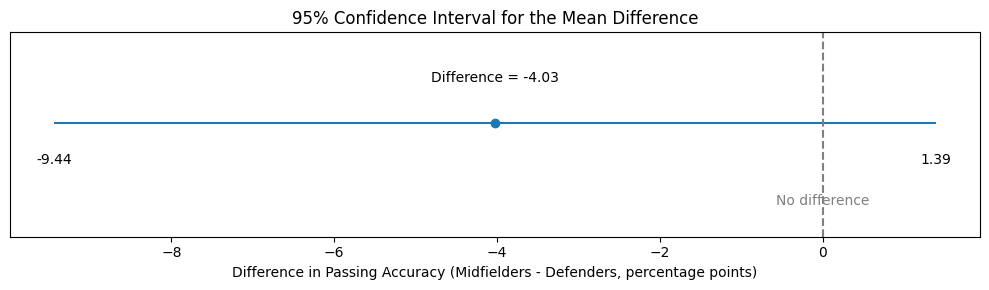

In [76]:
# Matplotlib's errorbar() displays the point estimate and confidence interval
# (Matplotlib development team, n.d.-a).
plt.figure(figsize=(10, 3))

# Draw the confidence interval and observed difference
# Requires asymmetric x-errors to be supplied as positive distances from plotted point
# (Matplotlib development team, n.d.-a).
plt.errorbar(mean_difference, 1, xerr=[[mean_difference - ci_lower], [ci_upper - mean_difference]], fmt="o")

# Zero represents no difference between the population means
plt.axvline(x=0, color="grey", linestyle="--")

# Add value labels
plt.text(ci_lower, 0.91, f"{ci_lower:.2f}", ha="center")
plt.text(mean_difference, 1.09, f"Difference = {mean_difference:.2f}", ha="center")
plt.text(ci_upper, 0.91, f"{ci_upper:.2f}", ha="center")
plt.text(0, 0.82, "No difference", ha="center", color="grey")

plt.yticks([])
plt.ylim(0.75, 1.20)

plt.xlabel("Difference in Passing Accuracy (Midfielders - Defenders, percentage points)")
plt.title("95% Confidence Interval for the Mean Difference")

plt.tight_layout()
plt.show()

## Inferential Statistics - Two-Sample t-test
A two-sample t-test is used to compare the mean accuracy of two independent groups: midfielders and defenders. In SciPy, `(ttest_ind(..., equal_var=False)` performs Welch's test (SciPy community, n.d.; Welch, 1947).

### Hypothesis
**Null hypothesis (H0):**
There is no difference in the mean passing accuracy of midfielders and defenders

**Alternate hypothesis (H1):**
There is a difference in the mean passing accuracy of midfielders and defenders

The significance level is set at:
alpa = 0.05

A two-tailed Welch's two-sample t-test is used because the two groups are independent.

### T-test interpretation
The test produced t(71.57) = -1.48, p =0.143
p > 0.05

Therefore the null hypothesis is not rejected.
95% CI for difference (-9.44 to 1.39)

Conclusion
Defenders had a higher mean than midfielders. However insuffient evidence at the 5% significance level to conclude the mean passing accuracy differed between the two groups.

Limitation
Passing accuracy analysed at player level.
Players with very few attempts contributed as much as a player with hundreds of attempts.

## Additional Visual Analysis
These figures describe the data and help identify limitations.


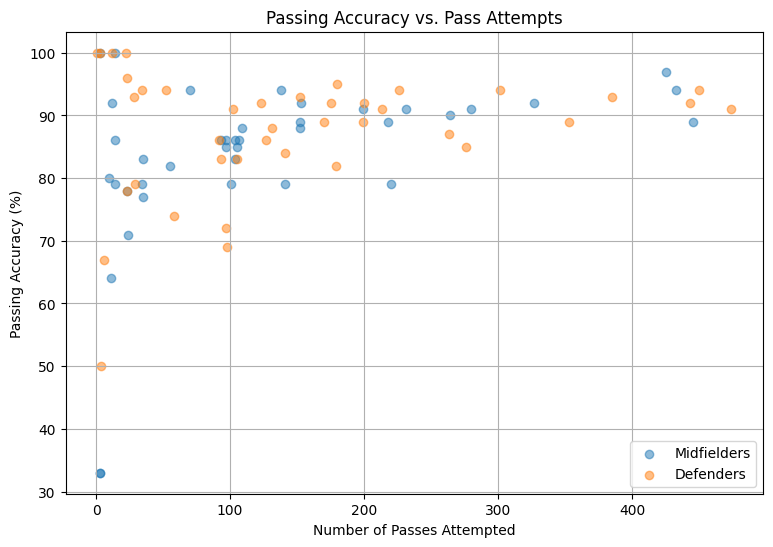

In [78]:
# Shows the relationship between two numerical variabkes.
# Each dot represents one player and compares their number of pass attempts with accuracy.
plt.figure(figsize=(9, 6))

plt.scatter(mf_sample["Passes"], mf_sample["PassingAccuracy"], label="Midfielders", alpha=0.5)
plt.scatter(df_sample["Passes"], df_sample["PassingAccuracy"], label="Defenders", alpha=0.5)

plt.title("Passing Accuracy vs. Pass Attempts")
plt.xlabel("Number of Passes Attempted")
plt.ylabel("Passing Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()

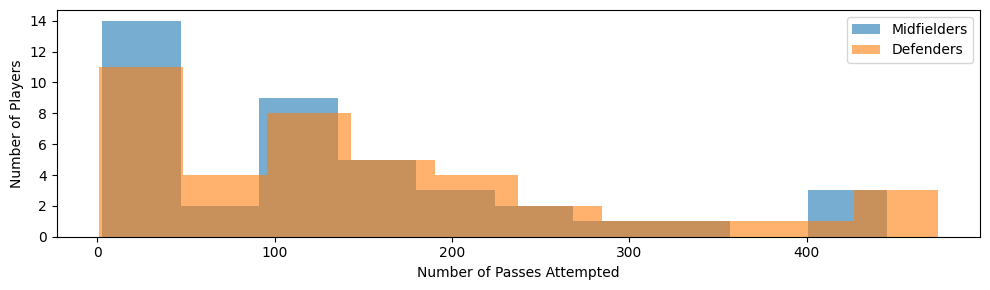

In [83]:
# This groups pass attempts into ranged showing how players fall within each range
# Makes it easier to where most values are found
plt.figure(figsize=(10, 3))

plt.hist(mf_sample["Passes"], bins=10, alpha=0.6, label="Midfielders")
plt.hist(df_sample["Passes"], bins=10, alpha=0.6, label="Defenders")

plt.xlabel("Number of Passes Attempted")
plt.ylabel("Number of Players")
plt.legend()

plt.tight_layout()
plt.show()

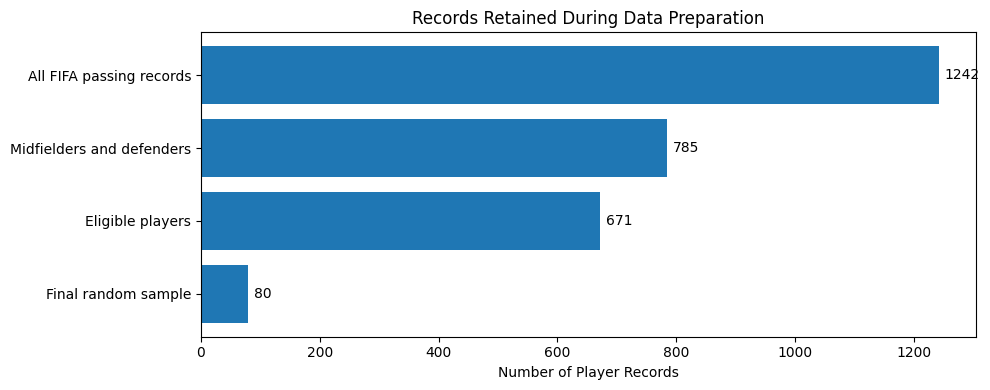

In [84]:
# This shows how the dataset became smaller during preparation.
# Filter the records used for Task 1
position_data = passing_df[passing_df["Position"].isin(["MF", "DF"])].copy()

eligible_data = position_data[(position_data["Passes"] > 0) & (position_data["PassingAccuracy"].notna())].copy()

# Count records retained at each stage
stage_counts = {
    "All FIFA passing records": len(passing_df),
    "Midfielders and defenders": len(position_data),
    "Eligible players": len(eligible_data),
    "Final random sample": len(mf_sample) + len(df_sample)
}

plt.figure(figsize=(10, 4))

plt.barh( list(stage_counts.keys()), list(stage_counts.values()))

for index, value in enumerate(stage_counts.values()):
    plt.text(value + 10, index, str(value), va="center")

plt.xlabel("Number of Player Records")
plt.title("Records Retained During Data Preparation")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [85]:
passing_df.to_csv("fifa_passing_all_players.csv", index=False)

task1_df.to_csv("task1_eligible_midfielders_defenders.csv", index=False)

task1_sample = pd.concat([mf_sample, df_sample])

task1_sample.to_csv("task1_random_sample.csv", index=False)

# References
Charles Darwin University, (2026a). HIT140 Week 3 learning material: Confidence intervals [Course learning material]. Learnline.

Charles Darwin University, (2026b). HIT140 Week 4 learning material: Hypothesis testing [Course learning material]. Learnline.

Fédération Internationale de Football Association (2026). FIFA World Cup 2026 player statistics. https://www.fifa.com/en/tournaments/mens/worldcup/canadamexicousa2026/statistics/player-statistics

IPython Development Team. (n.d.). Built-in magic commands. IPython documentation. Retrieved September 9, 2026, from https://ipython.readthedocs.io/en/stable/interactive/magics.html

Matplotlib Development Team (n.d.-a). matplotlib.pyplot.errorbar. Matplotlib documentation. Retrieved September 9, 2026, from https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.errorbar.html

Matplotlib Development Team (n.d.-b). Different ways of specifying error bars. Matplotlib documentation. Retrieved September 9, 2026, from https://matplotlib.org/stable/gallery/statistics/errorbar_features.html

Matplotlib Development Team (n.d-c) Matplotlin API reference. Matplotlib documentation. Retrieved September 9, 2026, from https://matplotlib.org/stable/api/index.html

McKinney, W. (2010). Data structures for statistical computing in Python. In S. van der Walt and J. Millman (Eds.), Proceedings of the 9th Python in Science Conference (pp.56-61). https://proceedings.scipy.org/articles/Majora-92bf1922-00a

Microsoft (n.d.-a). BrowserType. Playwright for Python. Retrieved September 9, 2026, from https://playwright.dev/python/docs/api/clas-browsertype#browser-type-launch

Microsoft. (n.d.-b). Evaluating Javascript. Playwright for Python. Retrieved September 9, 2026, from https://playwright.dev/python/docs/evaluating

Microsoft. (n.d.-c). Network. Playwright for Python. Retirieved September 9, 2026, from https://playwright.dev/python/docs/network

Microsoft. (n.d.-d). Installation. Playwright for Python. Retirieved September 9, 2026, from https://playwright.dev/python/docs/intro

Mozilla. (n.d.-a). encodeURIComponent(). MDN Web Docs. https://developer.mozilla.org/en-US/docs/Web/Javascript/Reference/Global_Objects/encodeURIComponent

National Institute of Standards and Technology. (2012). NIST/SEMATECH e-handbook of statistcal methods. https://www.itl.nist.gov/div898/handbook/

pandas Development Team. (n.d.-b). pandasDataFrame.sample. pandas documentation. Retrieved September 9,2026, from https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sample.html

pandas Development Team. (n.d.-b). pandas API reference. Retrieved September 9,2026, from https://pandas.pydata.org/docs/reference/index.html

Python Software Foundation. (n.d.-a). asyncio-Asynchronous I/O. Python documentation. Retrieved September 9, 2026, from https://docs.python.org/3/library/asyncio.html

Python Software Foundation. (n.d.-b). json-JSON encoder and decoder. Python 3 documentation. Retrieved September 9, 2026, from https://docs.python.org/3/library/json.html

Python Software Foundation. (n.d.-c). Date structures. Python 3 documentation. Retrieved September 9, 2026, from https://docs.python.org/3/tutorial/datastructures.html

Satterthwaite, F. E. (1946). An approximate distribution of estimates of variance components. Biometrics Bulletin, 2(6), 110-114.https://www.jstor.org/stable/3002019

SciPy Community. (n.d.). scipy.stats.ttest_ind. SciPy documentation. Retrieved September 9, 2026 from https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html

Ubuntu Manpage Repository. (n.d). xvfb-run-Run specified X client or command in a virtual X server environment. Retrieved September 9, 2026, from https://manpages.ubuntu.com/manpages/noble/man1/xvfb-run.1.html

Welch, B. L. (1947). The generalization of "Student's" problem when several different population variances are involved. Biometrika, 34(1-2), 28-35 https://academic.oup.com/biomet/article-abstract/34/1-2/28/210174


